So we have a pretty good model but now we want to perturb it a bit to see if we can do better ie get a better model in terms of out of sample rmse.

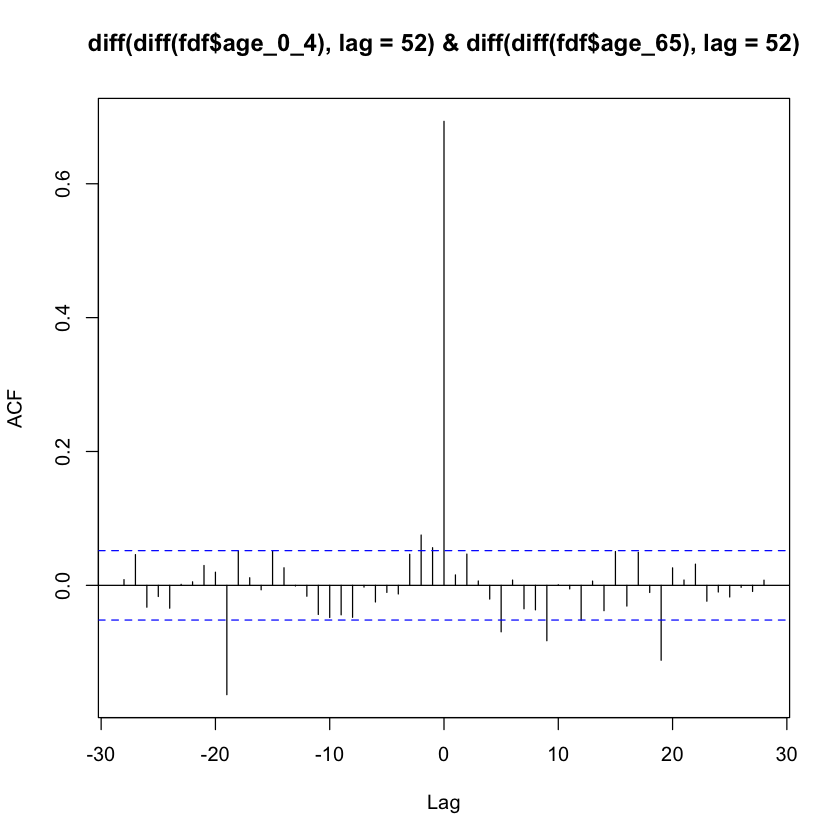

In [ ]:

library(smooth)
library(forecast)

fdf <- read.csv("data/fluview_clean/ilinet_final.csv")
y <- as.numeric(fdf$age_0_4)


# stopifnot(h < n)



out_of_sample_rmse <- function(data,orders){
    h <- 104
    n <- length(data)
    test_idx <- (n - h + 1):n
    sse <- 0
    for (i in seq_along(test_idx)) {
        t_idx <- test_idx[i]
        train_i <- data[1:(t_idx - 1)]
        fit_i <- msarima(
            train_i,
            orders = orders,
            lags = c(1, 52, 19)
        )
        fc_i <- forecast(fit_i, h = 1)
        sse <- sse + (data[t_idx]-fc_i$mean[1])^2
    }
    return (sqrt(sse / h))
}






# Evaluate on the last h points using rolling-origin 1-step forecasts
out_of_sample_rmse(y, orders = list(ar=c(1,0,1), i=c(1,1,0), ma=c(1,0,1)))



# # Rolling 1-step out-of-sample RMSE
# rmse_roll_1step <- sqrt(sse / h)

# # In-sample RMSE on the training block used for evaluation
# train0 <- y[1:(n - h)]
# fit_train0 <- msarima(
#   train0,
#   orders = list(ar = c(1, 1,1), i = c(1, 1,1), ma = c(1, 1,1)),
#   lags = c(1, 19, 52)
# )
# res_train0 <- tryCatch(as.numeric(residuals(fit_train0)),
#                        error = function(e) as.numeric(fit_train0$errors))
# rmse_insample <- sqrt(mean(res_train0^2, na.rm = TRUE))

In [58]:
# Now we want a funciton to vary the orders to see if we can do any better!!



perturb_orders <- function(orders, perturbation) {
    perturbed_orders <- lapply(orders, function(order) {
        sapply(order, function(x) max(x + sample(c(-1, 0, 1), 1), 0))
    })
    names(perturbed_orders) <- names(orders)
    return (perturbed_orders)
}




In [ ]:
# so now we can perturb and look for the best rmse

find_best_rmse_out_of_sample <- function(data, initial_orders, perturbation, iterations) {
    best_rmse <- out_of_sample_rmse(data, orders = initial_orders)
    current_orders <- initial_orders
    
    for (i in 1:iterations) {
        new_orders <- perturb_orders(current_orders, perturbation)
        rmse <- out_of_sample_rmse(data, orders = new_orders)
        
        if (rmse < best_rmse) {
            best_rmse <- rmse
            current_orders <- new_orders
        }
        
        cat("Iteration:", i, "Perturbed Orders:", new_orders, "RMSE:", rmse, "\n")
    }
    
    return (list(best_orders = current_orders, best_rmse = best_rmse))
}
find_best_rmse_out_of_sample(y, initial_orders = list(ar=c(1,0,1), i=c(1,1,0), ma=c(1,0,1)), perturbation = 1, iterations = 1)